# Настройка окружения и загрузка репозитория

In [1]:
!pip install kenlm jiwer

import sys, os, subprocess, math, heapq
from pathlib import Path
from typing import List, Tuple

import torch
import torchaudio
import kenlm
import jiwer
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import csv
from collections import defaultdict
import time

import urllib.request
import gzip
import shutil


# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.5/427.5 kB 27.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.4 MB/s eta 0:00:00
  Created wheel for kenlm: filename=kenlm-0.3.0-cp312-cp312-linux_x86_64.whl size=3188054 sha256=0842ddf7065f560c2dd76628570d4d8a1abe30a2d46b30a6ab7f8b17d43f074b
  Stored in directory: /root/.cache/pip/wheels/0c/e6/ad/18d2d3f1290a6be6a14a24e90f2b78bb3300aab3852ceb06a6
Successfully built kenlm


In [2]:
# Клонируем репозиторий задания, если ещё не сделано
REPO_DIR = Path('./asr_assignment2_repo')
if not REPO_DIR.exists():
    !git clone https://github.com/AntonOkhotnikov/ai-talent-hub-itmo-speech-course.git {REPO_DIR}
# Переход в папку assignment2
ASSIGN_DIR = REPO_DIR / 'assignments' / 'assignment2'
sys.path.insert(0, str(ASSIGN_DIR))

# Установка зависимостей (kenlm уже должен быть установлен отдельно, как описано в задании)
!pip install -r {ASSIGN_DIR / 'requirements.txt'} --quiet

os.chdir(str(ASSIGN_DIR))

Cloning into 'asr_assignment2_repo'...
remote: Enumerating objects: 631, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 631 (delta 23), reused 15 (delta 15), pack-reused 578 (from 1)
Receiving objects: 100% (631/631), 97.12 MiB | 5.28 MiB/s, done.
Resolving deltas: 100% (80/80), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.6 MB/s eta 0:00:00


In [3]:
from wav2vec2decoder import Wav2Vec2Decoder, _log_add
print("Wav2Vec2Decoder imported successfully")

# Проверка наличия модели и данных
print("Decoder module:", (ASSIGN_DIR / 'wav2vec2decoder.py').exists())
print("LM 3-gram:", (ASSIGN_DIR / 'lm' / '3-gram.pruned.1e-7.arpa.gz').exists())
print("Examples dir:", (ASSIGN_DIR / 'examples').exists())
print("Data (LibriSpeech test-other):", (ASSIGN_DIR / 'data' / 'librispeech_test_other').exists())
print("Data (Earnings22 test):", (ASSIGN_DIR / 'data' / 'earnings22_test').exists())

Wav2Vec2Decoder imported successfully
Decoder module: False
LM 3-gram: False
Examples dir: False
Data (LibriSpeech test-other): False
Data (Earnings22 test): False


# Часть 1 — CTC Decoding

## 1. Вспомогательные функции для оценки

In [4]:
def load_manifest(manifest_path: Path) -> List[Tuple[Path, str]]:
    """
    Читает манифест формата CSV с заголовком path,text.
    Возвращает список (абсолютный путь к .wav, текст транскрипции).
    """
    samples = []
    with open(manifest_path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rel_path = row['path'].strip()
            audio_path = Path(rel_path)
            if not audio_path.is_absolute():
                audio_path = Path.cwd() / audio_path
            transcript = row['text'].strip()
            samples.append((audio_path, transcript))
    return samples

def evaluate_decoder(decoder: Wav2Vec2Decoder,
                     manifest: List[Tuple[Path, str]],
                     method: str) -> Tuple[float, float]:
    """
    Вычисляет WER и CER для заданного метода декодирования на всём манифесте.
    """
    refs = []
    hyps = []
    for audio_path, ref in tqdm(manifest, desc=f"Evaluating {method}"):
        audio_input, sr = torchaudio.load(audio_path)
        assert sr == 16000, f"Sample rate {sr} instead of 16000 for {audio_path}"
        hyp = decoder.decode(audio_input, method=method)
        refs.append(ref)
        hyps.append(hyp)
    wer = jiwer.wer(refs, hyps)
    cer = jiwer.cer(refs, hyps)
    return wer, cer

## Задача 1 – Greedy Decoding

In [5]:
def greedy_decode(self, logits: torch.Tensor) -> str:
    """
    Perform greedy decoding (find best CTC path).
    """
    log_probs = torch.log_softmax(logits, dim=-1)
    best_ids = torch.argmax(log_probs, dim=-1)
    prev = None
    filtered_ids = []
    for idx in best_ids.tolist():
        if idx != self.blank_token_id and idx != prev:
            filtered_ids.append(idx)
        prev = idx
    return self._ids_to_text(filtered_ids)

Wav2Vec2Decoder.greedy_decode = greedy_decode

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/358 [00:00<?, ?B/s]

...

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded 200 test samples from LibriSpeech test-other


Evaluating greedy:   0%|          | 0/200 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Greedy Decoding -> WER: 0.1122 (11.22%), CER: 0.0381 (3.81%)
Reference WER ≈ 10.4%, CER ≈ 3.5%


In [ ]:
# Полная оценка на librispeech_test_other
decoder = Wav2Vec2Decoder(lm_model_path=None, temperature=1.0)
manifest_path = Path('data/librispeech_test_other/manifest.csv')
manifest = load_manifest(manifest_path)
print(f"Loaded {len(manifest)} test samples from LibriSpeech test-other")

wer_g, cer_g = evaluate_decoder(decoder, manifest, method="greedy")
print(f"Greedy Decoding -> WER: {wer_g:.4f} ({wer_g*100:.2f}%), CER: {cer_g:.4f} ({cer_g*100:.2f}%)")
print("Reference WER ≈ 10.4%, CER ≈ 3.5%")

## Задача 2 – Beam Search Decoding (без LM)

In [6]:
def beam_search_decode(self, logits: torch.Tensor, return_beams: bool = False):
    """
    CTC beam search без языковой модели.
    """
    log_probs = torch.log_softmax(logits, dim=-1)
    T, V = log_probs.shape
    blank = self.blank_token_id  # 0
    forbidden_tokens = {1, 2, 3}  # <s>, </s>, <unk>

    beams = [(0.0, [], blank)]

    for t in range(T):
        new_beams_dict = defaultdict(lambda: float('-inf'))
        for score, comp_ids, last_tok in beams:
            for c in range(V):
                if c in forbidden_tokens:
                    continue
                if c != blank and c == last_tok:
                    continue
                new_score = score + log_probs[t, c].item()

                if c == blank:
                    new_comp_ids = comp_ids
                    new_last = blank
                else:
                    new_comp_ids = comp_ids + [c]
                    new_last = c

                key = (tuple(new_comp_ids), new_last)
                if new_score > new_beams_dict[key]:
                    new_beams_dict[key] = new_score

        new_beams = []
        for (comp_ids_tuple, last_tok), sc in new_beams_dict.items():
            heapq.heappush(new_beams, (sc, list(comp_ids_tuple), last_tok))
            if len(new_beams) > self.beam_width:
                heapq.heappop(new_beams)

        beams = [(sc, comp_ids, last_tok) for sc, comp_ids, last_tok in new_beams]

    beams.sort(key=lambda x: x[0], reverse=True)

    if return_beams:
        return [(comp_ids, sc) for sc, comp_ids, _ in beams]

    best_ids = beams[0][1]
    return self._ids_to_text(best_ids)

Wav2Vec2Decoder.beam_search_decode = beam_search_decode

In [7]:
beam_widths = [1, 3, 10, 50]
results_beam = []
for bw in beam_widths:
    decoder = Wav2Vec2Decoder(lm_model_path=None, temperature=1.0, beam_width=bw)
    manifest_path = Path('data/librispeech_test_other/manifest.csv')
    manifest = load_manifest(manifest_path)
    wer, cer = evaluate_decoder(decoder, manifest, method="beam")
    results_beam.append((bw, wer, cer))
    print(f"Beam width {bw}: WER={wer*100:.2f}%, CER={cer*100:.2f}%")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam:   0%|          | 0/200 [00:00<?, ?it/s]

Beam width 1: WER=44.29%, CER=16.00%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

...

Beam width 10: WER=24.54%, CER=8.53%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam:   0%|          | 0/200 [00:00<?, ?it/s]

Beam width 50: WER=22.02%, CER=7.64%



Beam width experiments:
   Beam Width    WER    CER
0           1 0.4429 0.1600
1           3 0.2997 0.1054
2          10 0.2454 0.0853
3          50 0.2202 0.0764


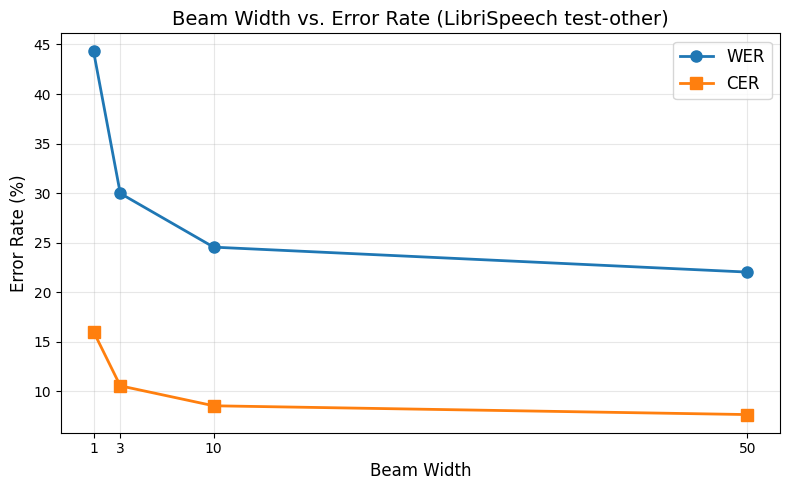

In [10]:
df_beam = pd.DataFrame(results_beam, columns=["Beam Width", "WER", "CER"])
print("\nBeam width experiments:")
print(df_beam.to_string(formatters={"WER": "{:.4f}".format, "CER": "{:.4f}".format}))

plt.figure(figsize=(8, 5))
plt.plot(df_beam["Beam Width"], df_beam["WER"]*100, marker='o', linewidth=2, markersize=8, label="WER")
plt.plot(df_beam["Beam Width"], df_beam["CER"]*100, marker='s', linewidth=2, markersize=8, label="CER")
plt.xlabel("Beam Width", fontsize=12)
plt.ylabel("Error Rate (%)", fontsize=12)
plt.title("Beam Width vs. Error Rate (LibriSpeech test-other)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(df_beam["Beam Width"])
plt.tight_layout()
plt.show()

In [ ]:
beam_widths = [1, 3, 10, 50]
results_beam = []
time_per_sample = []   # среднее время на один файл (сек)


test_audio, sr = torchaudio.load('examples/sample1.wav')
assert sr == 16000

for bw in beam_widths:
    decoder = Wav2Vec2Decoder(lm_model_path=None, temperature=1.0, beam_width=bw)
    trials = 5
    t_start = time.time()
    for _ in range(trials):
        _ = decoder.decode(test_audio, method="beam")
    t_elapsed = (time.time() - t_start) / trials

    manifest_path = Path('data/librispeech_test_other/manifest.csv')
    manifest = load_manifest(manifest_path)
    wer, cer = evaluate_decoder(decoder, manifest, method="beam")

    results_beam.append((bw, wer, cer))
    time_per_sample.append(t_elapsed)
    print(f"Beam width {bw:2d}: WER={wer*100:.2f}%, CER={cer*100:.2f}%, avg time={t_elapsed:.3f}s")

fig, ax1 = plt.subplots(figsize=(9, 5))

color_wer = '#e74c3c'
color_cer = '#3498db'
ax1.set_xlabel('Beam Width', fontweight='bold')
ax1.set_ylabel('Error Rate (%)', fontweight='bold')
ax1.plot(beam_widths, [w*100 for _,w,_ in results_beam],
         marker='o', color=color_wer, linewidth=2, markersize=8, label='WER')
ax1.plot(beam_widths, [c*100 for _,_,c in results_beam],
         marker='s', color=color_cer, linewidth=2, markersize=8, label='CER')
ax1.tick_params(axis='y')
ax1.set_xticks(beam_widths)
ax1.grid(True, linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
color_time = '#2ecc71'
ax2.set_ylabel('Decoding Time (seconds)', fontweight='bold', color=color_time)
ax2.plot(beam_widths, time_per_sample, marker='D', color=color_time,
         linewidth=2, markersize=8, linestyle='--', label='Time per utterance')
ax2.tick_params(axis='y', labelcolor=color_time)
ax2.set_ylim(bottom=0)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', frameon=True, fancybox=True)

plt.title('Beam Width: Quality vs. Compute Trade-off\n(LibriSpeech test-other)', fontweight='bold', fontsize=13)
fig.tight_layout()

fig.savefig('beam_width.png', dpi=300, bbox_inches='tight')
plt.show()

## Задача 3 – Temperature Scaling

In [ ]:
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
results_temp = []
manifest_path = Path('data/librispeech_test_other/manifest.csv')
manifest = load_manifest(manifest_path)

for T in temperatures:
    decoder = Wav2Vec2Decoder(lm_model_path=None, temperature=T)
    wer, cer = evaluate_decoder(decoder, manifest, method="greedy")
    results_temp.append((T, wer, cer))
    print(f"T={T:.1f}: WER={wer*100:.2f}%, CER={cer*100:.2f}%")


df_temp = pd.DataFrame(results_temp, columns=["Temperature", "WER", "CER"])

fig, ax1 = plt.subplots(figsize=(8, 5))

color_wer = '#e74c3c'
color_cer = '#3498db'
ax1.set_xlabel('Temperature', fontweight='bold', fontsize=12)
ax1.set_ylabel('WER / CER (%)', fontweight='bold', fontsize=12)
ax1.plot(df_temp["Temperature"], df_temp["WER"]*100, marker='o', color=color_wer,
         linewidth=2.5, markersize=10, label='WER')
ax1.plot(df_temp["Temperature"], df_temp["CER"]*100, marker='s', color=color_cer,
         linewidth=2.5, markersize=10, label='CER')
ax1.tick_params(axis='y')
ax1.set_xticks(temperatures)
ax1.grid(True, linestyle='--', alpha=0.4)

for i, (T, w, c) in enumerate(results_temp):
    ax1.annotate(f'{w*100:.2f}%', (T, w*100), textcoords="offset points", xytext=(0,10),
                 ha='center', fontsize=9, color=color_wer)
    ax1.annotate(f'{c*100:.2f}%', (T, c*100), textcoords="offset points", xytext=(0,-15),
                 ha='center', fontsize=9, color=color_cer)

plt.title('Greedy Decoding: Temperature vs. WER/CER\n(LibriSpeech test-other)', fontweight='bold', fontsize=13)
ax1.legend(loc='upper left', frameon=True, fancybox=True)
fig.tight_layout()

plt.savefig('temperature_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# Часть 2 — Language Model Integration

## Задача 4 – Beam Search with LM Shallow Fusion (3-gram)

In [8]:
def beam_search_with_lm(self, logits: torch.Tensor) -> str:
    """
    Beam search decoding with shallow LM fusion.
    score = log_p_acoustic + alpha * log_p_lm + beta * num_words
    """
    if not self.lm_model:
        raise ValueError("KenLM model required for LM shallow fusion")

    log_probs = torch.log_softmax(logits, dim=-1)
    T, V = log_probs.shape
    blank = self.blank_token_id  # 0
    word_delim = self.word_delimiter  # '|'
    space_token = ' '
    forbidden_tokens = {1, 2, 3}  # <s>, </s>, <unk>

    beams = [(0.0, [], blank, "", 0.0, 0)]

    for t in range(T):
        new_beams_dict = defaultdict(lambda: float('-inf'))
        best_entries = {}

        for score, token_ids, last_tok, lm_text, lm_cum, nwords in beams:
            for c in range(V):
                if c in forbidden_tokens:
                    continue
                if c != blank and c == last_tok:
                    continue

                new_score = score + log_probs[t, c].item()

                if c == blank:
                    final_score = new_score + self.alpha * lm_cum + self.beta * nwords
                    key = (tuple(token_ids), blank)
                    if final_score > new_beams_dict[key]:
                        new_beams_dict[key] = final_score
                        best_entries[key] = (token_ids, blank, lm_text, lm_cum, nwords)
                else:
                    new_ids = token_ids + [c]
                    char = self.vocab[c]
                    if char == word_delim:
                        new_lm_text = lm_text + space_token
                    else:
                        new_lm_text = lm_text + char.lower()

                    new_lm_cum = self.lm_model.score(new_lm_text.strip()) * math.log(10)
                    new_nwords = new_lm_text.strip().count(space_token)

                    final_score = new_score + self.alpha * new_lm_cum + self.beta * new_nwords
                    key = (tuple(new_ids), c)
                    if final_score > new_beams_dict[key]:
                        new_beams_dict[key] = final_score
                        best_entries[key] = (new_ids, c, new_lm_text, new_lm_cum, new_nwords)

        new_beams = []
        for (comp_ids_tuple, last_tok), sc in new_beams_dict.items():
            ids, last, lm_txt, lm_c, nw = best_entries[(comp_ids_tuple, last_tok)]
            heapq.heappush(new_beams, (sc, ids, last, lm_txt, lm_c, nw))
            if len(new_beams) > self.beam_width:
                heapq.heappop(new_beams)

        beams = [(sc, ids, last, lm_txt, lm_c, nw) for sc, ids, last, lm_txt, lm_c, nw in new_beams]

    beams.sort(key=lambda x: x[0], reverse=True)
    best_ids = beams[0][1]
    return self._ids_to_text(best_ids)

Wav2Vec2Decoder.beam_search_with_lm = beam_search_with_lm

In [ ]:
alphas = [0.01, 0.05, 0.1, 0.5]
betas = [0.0, 0.5, 1.0, 1.5]

results_sf = []
manifest_path = Path('data/librispeech_test_other/manifest.csv')
manifest = load_manifest(manifest_path)

total_combinations = len(alphas) * len(betas)
current = 0

for alpha in alphas:
    for beta in betas:
        current += 1
        print(f"\n[{current}/{total_combinations}] Testing α={alpha:.2f}, β={beta:.1f}...")
        decoder = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=10,
            alpha=alpha,
            beta=beta,
            temperature=1.0
        )
        wer, cer = evaluate_decoder(decoder, manifest, method="beam_lm")
        results_sf.append((alpha, beta, wer, cer))
        print(f"α={alpha:.2f}, β={beta:.1f}: WER={wer*100:.2f}%, CER={cer*100:.2f}%")

df_sf = pd.DataFrame(results_sf, columns=["alpha", "beta", "WER", "CER"])
print("\nShallow Fusion Results:")
print(df_sf.to_string(formatters={"WER": "{:.4f}".format, "CER": "{:.4f}".format}))

best_row = df_sf.loc[df_sf['WER'].idxmin()]
print(f"\nBest configuration: α={best_row['alpha']:.2f}, β={best_row['beta']:.1f}")
print(f"WER={best_row['WER']*100:.2f}%, CER={best_row['CER']*100:.2f}%")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap WER
pivot_wer = df_sf.pivot(index="beta", columns="alpha", values="WER")
im1 = axes[0].imshow(pivot_wer, cmap='RdYlGn_r', aspect='auto', origin='lower')
axes[0].set_xticks(range(len(alphas)))
axes[0].set_xticklabels([f'{a:.2f}' for a in alphas])
axes[0].set_yticks(range(len(betas)))
axes[0].set_yticklabels([f'{b:.1f}' for b in betas])
axes[0].set_xlabel('α (LM weight)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('β (word bonus)', fontweight='bold', fontsize=11)
axes[0].set_title('WER Heatmap', fontweight='bold', fontsize=13)
plt.colorbar(im1, ax=axes[0], label='WER')
for i in range(len(betas)):
    for j in range(len(alphas)):
        text = axes[0].text(j, i, f'{pivot_wer.iloc[i,j]*100:.2f}%',
                           ha="center", va="center", color="black", fontsize=9)

# Heatmap CER
pivot_cer = df_sf.pivot(index="beta", columns="alpha", values="CER")
im2 = axes[1].imshow(pivot_cer, cmap='RdYlGn_r', aspect='auto', origin='lower')
axes[1].set_xticks(range(len(alphas)))
axes[1].set_xticklabels([f'{a:.2f}' for a in alphas])
axes[1].set_yticks(range(len(betas)))
axes[1].set_yticklabels([f'{b:.1f}' for b in betas])
axes[1].set_xlabel('α (LM weight)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('β (word bonus)', fontweight='bold', fontsize=11)
axes[1].set_title('CER Heatmap', fontweight='bold', fontsize=13)
plt.colorbar(im2, ax=axes[1], label='CER')
for i in range(len(betas)):
    for j in range(len(alphas)):
        text = axes[1].text(j, i, f'{pivot_cer.iloc[i,j]*100:.2f}%',
                           ha="center", va="center", color="black", fontsize=9)

plt.suptitle('Shallow Fusion: α vs β (3-gram LM, LibriSpeech test-other)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('shallow_fusion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Задача 5 – 4-gram LM Evaluation

In [ ]:
lm_dir = Path('lm')
lm_dir.mkdir(exist_ok=True)

url_4gram = "https://www.openslr.org/resources/11/4-gram.arpa.gz"
local_4gram_gz = lm_dir / "4-gram.arpa.gz"
local_4gram = lm_dir / "4-gram.arpa"

if not local_4gram_gz.exists():
    print(f"Downloading 4-gram LM from {url_4gram} ...")
    urllib.request.urlretrieve(url_4gram, local_4gram_gz)
    print("Downloaded.")
else:
    print("4-gram LM already downloaded.")

assert local_4gram_gz.exists(), "4-gram LM file missing!"

best_alpha = 0.01
best_beta = 1.0

decoder_4gram = Wav2Vec2Decoder(
    lm_model_path=str(local_4gram_gz),
    beam_width=10,
    alpha=best_alpha,
    beta=best_beta,
    temperature=1.0
)

manifest_path = Path('data/librispeech_test_other/manifest.csv')
manifest = load_manifest(manifest_path)

wer_4gram, cer_4gram = evaluate_decoder(decoder_4gram, manifest, method="beam_lm")
print(f"4-gram LM: WER={wer_4gram*100:.2f}%, CER={cer_4gram*100:.2f}%")

## Задача 6 – Second-pass LM Rescoring

In [9]:
def lm_rescore(self, beams: List[Tuple[List[int], float]]) -> str:
    """
    Perform second-pass LM rescoring on beam search outputs.
    Args:
        beams: list of (token_ids, log_prob) from beam_search_decode(return_beams=True)
    Returns:
        str: best rescored transcript
    """
    if not self.lm_model:
        raise ValueError("KenLM model required for LM rescoring")

    best_score = float('-inf')
    best_text = ""
    for token_ids, acoustic_logprob in beams:
        text = self._ids_to_text(token_ids)
        if not text.strip():
            lm_logprob = 0.0
            num_words = 0
        else:
            lm_logprob = self.lm_model.score(text) * math.log(10)
            num_words = len(text.split())
        total_score = acoustic_logprob + self.alpha * lm_logprob + self.beta * num_words
        if total_score > best_score:
            best_score = total_score
            best_text = text
    return best_text


Wav2Vec2Decoder.lm_rescore = lm_rescore

In [11]:
alphas = [0.01, 0.05, 0.1, 0.5]
betas = [0.0, 0.5, 1.0, 1.5]

manifest_path = Path('data/librispeech_test_other/manifest.csv')
manifest = load_manifest(manifest_path)

print("Extracting beams for all utterances...")
all_beams = []
references = []
for audio_path, ref in tqdm(manifest, desc="Beam extraction"):
    audio_input, sr = torchaudio.load(audio_path)
    assert sr == 16000

    temp_decoder = Wav2Vec2Decoder(lm_model_path=None, beam_width=10, temperature=1.0)
    beams = temp_decoder.decode(audio_input, method="beam")
    inputs = temp_decoder.processor(audio_input, return_tensors="pt", sampling_rate=16000)
    with torch.no_grad():
        logits = temp_decoder.model(inputs.input_values.squeeze(0)).logits[0]
    logits = logits / temp_decoder.temperature
    beams = temp_decoder.beam_search_decode(logits, return_beams=True)
    all_beams.append(beams)
    references.append(ref)

results_rescore = []
for alpha in alphas:
    for beta in betas:
        print(f"Rescoring with α={alpha:.2f}, β={beta:.1f}...")
        hyps = []

        rescore_decoder = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=10,
            alpha=alpha,
            beta=beta,
            temperature=1.0
        )
        for beams_per_utt in tqdm(all_beams, desc=f"Rescoring α={alpha:.2f} β={beta:.1f}", leave=False):
            best_hyp = rescore_decoder.lm_rescore(beams_per_utt)
            hyps.append(best_hyp)
        wer = jiwer.wer(references, hyps)
        cer = jiwer.cer(references, hyps)
        results_rescore.append((alpha, beta, wer, cer))
        print(f"α={alpha:.2f}, β={beta:.1f}: WER={wer*100:.2f}%, CER={cer*100:.2f}%")

Extracting beams for all utterances...


Beam extraction:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

...

α=0.50, β=1.0: WER=24.88%, CER=8.60%
Rescoring with α=0.50, β=1.5...


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Rescoring α=0.50 β=1.5:   0%|          | 0/200 [00:00<?, ?it/s]

α=0.50, β=1.5: WER=24.96%, CER=8.67%


In [ ]:
df_rescore = pd.DataFrame(results_rescore, columns=["alpha", "beta", "WER", "CER"])

# Heatmap WER rescoring
pivot_wer_r = df_rescore.pivot(index="beta", columns="alpha", values="WER")
plt.figure(figsize=(8, 5))
plt.imshow(pivot_wer_r, cmap='RdYlGn_r', aspect='auto', origin='lower')
plt.colorbar(label='WER')
plt.xticks(range(len(alphas)), [f'{a:.2f}' for a in alphas])
plt.yticks(range(len(betas)), [f'{b:.1f}' for b in betas])
plt.xlabel('α (LM weight)', fontweight='bold')
plt.ylabel('β (word bonus)', fontweight='bold')
plt.title('Rescoring WER Heatmap (LibriSpeech test-other)', fontweight='bold')
for i in range(len(betas)):
    for j in range(len(alphas)):
        plt.text(j, i, f'{pivot_wer_r.iloc[i,j]*100:.2f}%', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('task6_rescore_heatmap.png', dpi=150)
plt.show()

# Сравнение лучших результатов двух методов
best_sf = df_sf.loc[df_sf['WER'].idxmin()]
best_rs = df_rescore.loc[df_rescore['WER'].idxmin()]

print("Comparison of best shallow fusion vs rescoring (3-gram LM):")
print(f"Shallow Fusion: WER={best_sf['WER']*100:.2f}%, CER={best_sf['CER']*100:.2f}% (α={best_sf['alpha']:.2f}, β={best_sf['beta']:.1f})")
print(f"Rescoring:      WER={best_rs['WER']*100:.2f}%, CER={best_rs['CER']*100:.2f}% (α={best_rs['alpha']:.2f}, β={best_rs['beta']:.1f})")

In [ ]:
interesting_indices = []
for idx, (beams_per_utt, ref) in enumerate(zip(all_beams, references)):
    beam_text = rescore_decoder._ids_to_text(beams_per_utt[0][0]) if beams_per_utt else ""

    audio_path, _ = manifest[idx]
    audio_input, sr = torchaudio.load(audio_path)

    # SF
    sf_decoder = Wav2Vec2Decoder(lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
                                 beam_width=10, alpha=best_sf['alpha'], beta=best_sf['beta'], temperature=1.0)
    sf_text = sf_decoder.decode(audio_input, method="beam_lm")

    # RS
    rs_decoder = Wav2Vec2Decoder(lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
                                 beam_width=10, alpha=best_rs['alpha'], beta=best_rs['beta'], temperature=1.0)
    rs_text = rs_decoder.lm_rescore(beams_per_utt)

    if beam_text != sf_text or beam_text != rs_text or sf_text != rs_text:
        interesting_indices.append(idx)
        if len(interesting_indices) >= 10:
            break

for idx in interesting_indices:
    audio_path, ref = manifest[idx]
    audio_input, _ = torchaudio.load(audio_path)
    beams = all_beams[idx]
    beam_text = rescore_decoder._ids_to_text(beams[0][0])
    sf_text = sf_decoder.decode(audio_input, method="beam_lm")
    rs_text = rs_decoder.lm_rescore(beams)
    print(f"REF : {ref}")
    print(f"BEAM: {beam_text}")
    print(f"SF  : {sf_text}")
    print(f"RS  : {rs_text}")
    if sf_text == ref:
        print("  SF  ✓ corrected")
    elif sf_text != beam_text:
        print("  SF  changed")
    if rs_text == ref:
        print("  RS  ✓ corrected")
    elif rs_text != beam_text:
        print("  RS  changed")
    print("-" * 60)

In [ ]:
beta_fixed = best_sf['beta']
alphas_range = alphas
wer_sf_fixed = []
wer_rs_fixed = []
for a in alphas_range:

    # SF
    dec_sf = Wav2Vec2Decoder(lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
                            beam_width=10, alpha=a, beta=beta_fixed, temperature=1.0)
    wer_sf, _ = evaluate_decoder(dec_sf, manifest, method="beam_lm")
    wer_sf_fixed.append(wer_sf)

    # RS
    dec_rs = Wav2Vec2Decoder(lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
                            beam_width=10, alpha=a, beta=beta_fixed, temperature=1.0)
    hyps = []
    for beams_per_utt in all_beams:
        hyps.append(dec_rs.lm_rescore(beams_per_utt))
    wer_rs = jiwer.wer(references, hyps)
    wer_rs_fixed.append(wer_rs)

plt.figure(figsize=(8, 5))
plt.plot(alphas_range, [w*100 for w in wer_sf_fixed], marker='o', label='Shallow Fusion')
plt.plot(alphas_range, [w*100 for w in wer_rs_fixed], marker='s', label='Rescoring')
plt.xlabel('α (LM weight)')
plt.ylabel('WER (%)')
plt.title(f'Stability to α (β={beta_fixed})')
plt.legend()
plt.grid(True)
plt.savefig('task6_stability.png', dpi=150)
plt.show()

## Задача 7 – Out-of-Domain Evaluation (Earnings22)

In [12]:
earnings_manifest_path = Path('data/earnings22_test/manifest.csv')
earnings_manifest = load_manifest(earnings_manifest_path)
print(f"Loaded {len(earnings_manifest)} samples from Earnings22 test")

best_sf_alpha = 0.01
best_sf_beta = 1.0
best_rs_alpha = 0.5
best_rs_beta = 0.5
beam_width = 50


configs = {
    "greedy": {"lm": None, "alpha": 0, "beta": 0, "temp": 1.0, "bw": 1},
    "beam": {"lm": None, "alpha": 0, "beta": 0, "temp": 1.0, "bw": beam_width},
    "beam_lm": {"lm": "lm/3-gram.pruned.1e-7.arpa.gz", "alpha": best_sf_alpha, "beta": best_sf_beta, "temp": 1.0, "bw": beam_width},
    "beam_lm_rescore": {"lm": "lm/3-gram.pruned.1e-7.arpa.gz", "alpha": best_rs_alpha, "beta": best_rs_beta, "temp": 1.0, "bw": beam_width}
}

results_earnings = {}
for method, cfg in configs.items():
    decoder = Wav2Vec2Decoder(
        lm_model_path=cfg["lm"],
        beam_width=cfg["bw"],
        alpha=cfg["alpha"],
        beta=cfg["beta"],
        temperature=cfg["temp"]
    )
    wer, cer = evaluate_decoder(decoder, earnings_manifest, method=method)
    results_earnings[method] = (wer, cer)
    print(f"{method:20s}: WER={wer*100:.2f}%, CER={cer*100:.2f}%")

Loaded 200 samples from Earnings22 test


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating greedy:   0%|          | 0/200 [00:00<?, ?it/s]

greedy              : WER=54.97%, CER=25.58%


...

beam_lm             : WER=116.30%, CER=39.13%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam_lm_rescore:   0%|          | 0/200 [00:00<?, ?it/s]

beam_lm_rescore     : WER=59.01%, CER=27.23%


### 7a – сравнение всех методов

In [13]:
libri = {
    "greedy": (0.1122, 0.0381),
    "beam": (0.2202, 0.0764),
    "beam_lm": (0.2315, 0.0803),
    "beam_lm_rescore": (0.2435, 0.0844 )
}

methods_order = ["greedy", "beam", "beam_lm", "beam_lm_rescore"]
table_data = []
for m in methods_order:
    l_wer, l_cer = libri[m]
    e_wer, e_cer = results_earnings[m]
    table_data.append([m, l_wer, l_cer, e_wer, e_cer])

df_comp = pd.DataFrame(table_data, columns=["Method", "LibriSpeech WER", "LibriSpeech CER", "Earnings22 WER", "Earnings22 CER"])
df_comp.set_index("Method", inplace=True)

format_dict = {col: "{:.2%}".format for col in df_comp.columns}
print("\nComparison of all methods on In-Domain vs Out-of-Domain:")
print(df_comp.to_string(formatters=format_dict))


Comparison of all methods on In-Domain vs Out-of-Domain:
                LibriSpeech WER LibriSpeech CER Earnings22 WER Earnings22 CER
Method                                                                       
greedy                   11.22%           3.81%         54.97%         25.58%
beam                     22.02%           7.64%         59.64%         27.32%
beam_lm                  23.15%           8.03%        116.30%         39.13%
beam_lm_rescore          24.35%           8.44%         59.01%         27.23%


### 7b – Temperature Sweep на Earnings22 с LM

In [ ]:
temperatures = [0.5, 1.0, 1.5, 2.0]
greedy_wer_temp = []
sf_wer_temp = []

for T in temperatures:
    dec_g = Wav2Vec2Decoder(lm_model_path=None, temperature=T)
    wer_g, _ = evaluate_decoder(dec_g, earnings_manifest, method="greedy")
    greedy_wer_temp.append(wer_g)

    dec_sf = Wav2Vec2Decoder(
        lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
        beam_width=beam_width, alpha=best_sf_alpha, beta=best_sf_beta, temperature=T
    )
    wer_sf, _ = evaluate_decoder(dec_sf, earnings_manifest, method="beam_lm")
    sf_wer_temp.append(wer_sf)

    print(f"T={T:.1f}: Greedy WER={wer_g*100:.2f}%, SF WER={wer_sf*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(temperatures, [w*100 for w in greedy_wer_temp], marker='o', linewidth=2, label='Greedy (Earnings22)')
plt.plot(temperatures, [w*100 for w in sf_wer_temp], marker='s', linewidth=2, label='Shallow Fusion (Earnings22)')
plt.xlabel('Temperature', fontweight='bold')
plt.ylabel('WER (%)', fontweight='bold')
plt.title('Effect of Temperature on Out-of-Domain Decoding (Earnings22)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(temperatures)
plt.tight_layout()
plt.savefig('task7b_temperature_earnings22.png', dpi=150)
plt.show()

## Задача 8 – Обучение финансовой KenLM

In [14]:
!apt-get update -qq && apt-get install -y -qq cmake libboost-all-dev 2>&1 | tail -5

kenlm_build_dir = Path("/tmp/kenlm_build")
if not kenlm_build_dir.exists():
    !git clone --depth=1 https://github.com/kpu/kenlm /tmp/kenlm_build
    !mkdir -p /tmp/kenlm_build/build && cd /tmp/kenlm_build/build && cmake .. && make -j4 lmplz build_binary
else:
    print("KenLM build directory already exists, skipping compilation.")

lmplz_path = "/tmp/kenlm_build/build/bin/lmplz"
build_binary_path = "/tmp/kenlm_build/build/bin/build_binary"
print("lmplz exists:", os.path.isfile(lmplz_path))
print("build_binary exists:", os.path.isfile(build_binary_path))

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc_proxy.so.2 is not a symbolic link

Cloning into '/tmp/kenlm_build'...
remote: Enumerating objects: 319, done.
remote: Counting objects: 100% (319/319), done.
remote: Compressing objects: 100% (310/310), done.
remote: Total 319 (delta 15), reused 227 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (319/319), 493.07 KiB | 16.44 MiB/s, done.
Resolving deltas: 100% (15/15), done.
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- De

In [15]:
lm_dir = Path('lm')
lm_dir.mkdir(exist_ok=True)

corpus_path = "data/earnings22_train/corpus.txt"
output_arpa = "/tmp/financial-3gram.arpa"
output_gz = lm_dir / "financial-3gram.arpa.gz"

!{lmplz_path} -o 3 --discount_fallback < {corpus_path} > {output_arpa}

!gzip -c {output_arpa} > {output_gz}
print(f"Model saved to {output_gz}")

=== 1/5 Counting and sorting n-grams ===
Reading /content/asr_assignment2_repo/assignments/assignment2/data/earnings22_train/corpus.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 101181 types 5701
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:68412 2:3785944320 3:7098645504
Statistics:
1 5701 D1=0.568292 D2=1.02526 D3+=1.54415
2 42688 D1=0.761144 D2=1.14769 D3+=1.46089
3 77164 D1=0.868472 D2=1.23411 D3+=1.48545
Memory estimate for binary LM:
type      kB
probing 2501 assuming -p 1.5
probing 2774 assuming -r models -p 1.5
trie    1032 without quantization
trie     574 assuming -q 8 -b 8 quantization 
trie     984 assuming -a 22 array pointer compression
trie     526 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain

In [16]:
import kenlm
fin_lm = kenlm.Model(str(output_gz))
print("Vocabulary size:", fin_lm.order)

test_sentences = ["revenue increased by ten percent", "operating surplus is a non gaap financial measure"]
for s in test_sentences:
    score = fin_lm.score(s)
    print(f"'{s}' -> log10 prob: {score:.3f}")

Vocabulary size: 3
'revenue increased by ten percent' -> log10 prob: -13.803
'operating surplus is a non gaap financial measure' -> log10 prob: -22.611


## Задача 9 – Сравнение LMs на обоих доменах

In [18]:
# Пути к языковым моделям
lm_libri = "lm/3-gram.pruned.1e-7.arpa.gz"
lm_fin = "lm/financial-3gram.arpa.gz"

assert os.path.isfile(lm_fin), "Financial LM not found! Run Task 8 first."

manifest_ls = load_manifest(Path('data/librispeech_test_other/manifest.csv'))

def evaluate_method(lm_path, method, alpha, beta, manifest):
    decoder = Wav2Vec2Decoder(
        lm_model_path=lm_path,
        beam_width=beam_width,
        alpha=alpha,
        beta=beta,
        temperature=1.0
    )
    return evaluate_decoder(decoder, manifest, method=method)

ls_results = {}

ls_results['SF_libri'] = evaluate_method(lm_libri, 'beam_lm', best_sf_alpha, best_sf_beta, manifest_ls)
ls_results['RS_libri'] = evaluate_method(lm_libri, 'beam_lm_rescore', best_rs_alpha, best_rs_beta, manifest_ls)

ls_results['SF_fin'] = evaluate_method(lm_fin, 'beam_lm', best_sf_alpha, best_sf_beta, manifest_ls)
ls_results['RS_fin'] = evaluate_method(lm_fin, 'beam_lm_rescore', best_rs_alpha, best_rs_beta, manifest_ls)

print("LibriSpeech test-other:")
for k, (wer, cer) in ls_results.items():
    print(f"  {k}: WER={wer*100:.2f}%, CER={cer*100:.2f}%")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam_lm:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Evaluating beam_lm:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam_lm_rescore:   0%|          | 0/200 [00:00<?, ?it/s]

LibriSpeech test-other:
  SF_libri: WER=88.71%, CER=24.27%
  RS_libri: WER=21.85%, CER=7.53%
  SF_fin: WER=90.91%, CER=25.20%
  RS_fin: WER=21.44%, CER=7.36%


In [19]:
manifest_earn = load_manifest(Path('data/earnings22_test/manifest.csv'))

earn_results = {}

earn_results['SF_libri'] = evaluate_method(lm_libri, 'beam_lm', best_sf_alpha, best_sf_beta, manifest_earn)
earn_results['RS_libri'] = evaluate_method(lm_libri, 'beam_lm_rescore', best_rs_alpha, best_rs_beta, manifest_earn)

earn_results['SF_fin'] = evaluate_method(lm_fin, 'beam_lm', best_sf_alpha, best_sf_beta, manifest_earn)
earn_results['RS_fin'] = evaluate_method(lm_fin, 'beam_lm_rescore', best_rs_alpha, best_rs_beta, manifest_earn)

print("Earnings22 test:")
for k, (wer, cer) in earn_results.items():
    print(f"  {k}: WER={wer*100:.2f}%, CER={cer*100:.2f}%")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam_lm:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Evaluating beam_lm:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating beam_lm_rescore:   0%|          | 0/200 [00:00<?, ?it/s]

Earnings22 test:
  SF_libri: WER=116.30%, CER=39.13%
  RS_libri: WER=59.01%, CER=27.23%
  SF_fin: WER=119.10%, CER=39.58%
  RS_fin: WER=57.14%, CER=26.92%


In [20]:
data = []
for method_lm in ['SF_libri', 'RS_libri', 'SF_fin', 'RS_fin']:
    ls_wer, ls_cer = ls_results[method_lm]
    earn_wer, earn_cer = earn_results[method_lm]
    data.append([method_lm, ls_wer, ls_cer, earn_wer, earn_cer])

df_final = pd.DataFrame(data, columns=['Method+LM', 'Libri WER', 'Libri CER', 'Earnings WER', 'Earnings CER'])
df_final.set_index('Method+LM', inplace=True)
print("Comparison of LMs across domains:")
print(df_final.to_string(formatters={col: '{:.2%}'.format for col in df_final.columns}))

Comparison of LMs across domains:
          Libri WER Libri CER Earnings WER Earnings CER
Method+LM                                              
SF_libri     88.71%    24.27%      116.30%       39.13%
RS_libri     21.85%     7.53%       59.01%       27.23%
SF_fin       90.91%    25.20%      119.10%       39.58%
RS_fin       21.44%     7.36%       57.14%       26.92%


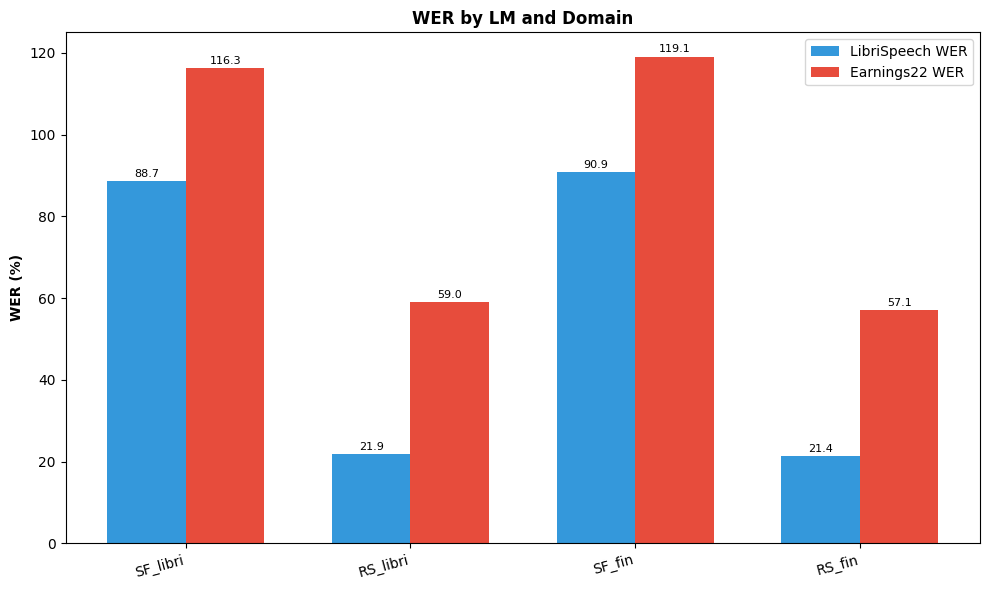

In [21]:
labels = df_final.index.tolist()
libri_wer = df_final['Libri WER'].values * 100
earn_wer = df_final['Earnings WER'].values * 100

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, libri_wer, width, label='LibriSpeech WER', color='#3498db')
bars2 = ax.bar(x + width/2, earn_wer, width, label='Earnings22 WER', color='#e74c3c')

ax.set_ylabel('WER (%)', fontweight='bold')
ax.set_title('WER by LM and Domain', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('task9_lm_domain_comparison.png', dpi=150)
plt.show()